## Проект "Анализ продаж лекарственных препаратов по ATC за 2014-2019 год"

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
daily = pd.read_csv('salesdaily.csv',parse_dates=['datum'])
monthly = pd.read_csv('salesmonthly.csv',parse_dates=['datum'])

In [3]:
daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [4]:
monthly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


## Столбцы в таблице daily:
 - datum - дата
 - M01AB - производные уксусной кислоты
 - M01AE - производные пропионовой кислоты
 - N02BA - салицилаты
 - N02BE/B - анилиды
 - N05B - анксиолитики 
 - N05C - снотворные и седативные средства
 - R03 - препараты, предназначенная для лечения обструктивных заболеваний дыхательных путей
 - R06 - антигистаминные
 - Year - год
 - Month - месяц
 - Hour - час
 - Weekday Name - день недели 

## Цель проекта:
 провести комплексный анализ временной динамики продаж фармацевтических препаратов, выявить структуру рынка, сезонные паттерны и долгосрочные тренды для оценки устойчивости и перспектив роста отдельных терапевтических категорий.

## Подготовка данных для дальнейшего анализа

In [6]:
#обработка пропусков 
daily.isna().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [7]:
monthly.isna().sum()

datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

In [ ]:
daily.shape

In [ ]:
monthly.shape

In [ ]:
#типы данных 
daily.dtypes

In [ ]:
monthly.dtypes

In [8]:
#Обработка пропусков по датам
dates_expected = pd.date_range(start='2014-01-01', end='2019-12-31', freq='M')
dates_in_df = pd.to_datetime(daily['datum'].dt.strftime('%Y-%m-%d')).unique()

for year in range(2014, 2020):
    missing_dates = [date for date in dates_expected if date.year == year and date not in dates_in_df]
    if missing_dates:
        print(f"Год {year}: Данные отсутствуют - {missing_dates}")
    else:
        print(f"Год {year}: Данные присутствуют")

Год 2014: Данные присутствуют
Год 2015: Данные присутствуют
Год 2016: Данные присутствуют
Год 2017: Данные присутствуют
Год 2018: Данные присутствуют
Год 2019: Данные отсутствуют - [Timestamp('2019-10-31 00:00:00', freq='M'), Timestamp('2019-11-30 00:00:00', freq='M'), Timestamp('2019-12-31 00:00:00', freq='M')]


В анализе отсутствуют последние 3 месяца 2019 года, что может незначительно влиять на сезонные оценки.

In [9]:
#выделим столбцы с категориями
atc = daily.columns[1:9]

## Топ-категории по продажам

In [11]:
total_by_category = daily[atc].sum().sort_values(ascending=False)

In [12]:
daily['Total_Sales'] = daily[atc].sum(axis=1)

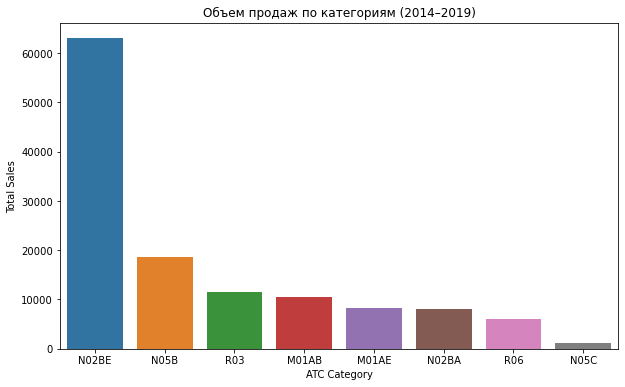

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=total_by_category.index,
            y=total_by_category.values)

plt.title('Объем продаж по категориям (2014–2019)')
plt.xlabel('ATC Category')
plt.ylabel('Total Sales')
plt.show()


In [33]:
category_share = round((total_by_category/total_by_category.sum())*100,2)
category_share

N02BE    49.38
N05B     14.61
R03       9.10
M01AB     8.31
M01AE     6.43
N02BA     6.40
R06       4.79
N05C      0.98
dtype: float64

NO2BE-категория формирует 49.38% общего объема продаж, что указывает на доминирующую позицию в структуре рынка.

## Исследование с использованием скользящего среднего

In [14]:
daily = daily.set_index('datum')
monthly = monthly.set_index('datum')

In [15]:
daily_365d = daily[atc].rolling(365, center=True).mean()


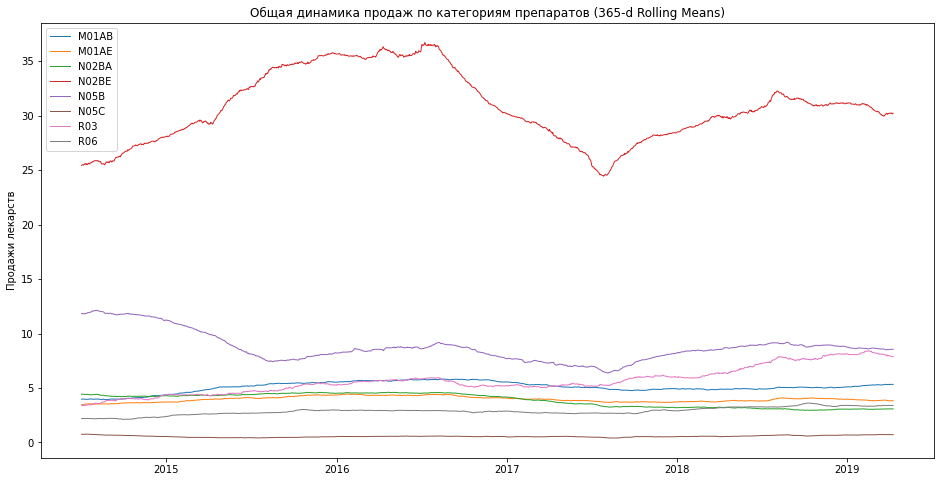

In [16]:
fig, ax = plt.subplots(figsize=(16, 8))
for nm in atc:
    ax.plot(daily_365d[nm], label=nm, linestyle='-', linewidth=1)
    ax.legend()
    ax.set_ylabel('Продажи лекарств')
    ax.set_title('Общая динамика продаж по категориям препаратов (365-d Rolling Means)')


Долгосрочный тренд демонстрирует умеренный рост продаж в большинстве категорий. Особенно выреженный рост присутствует в классе N.

## Выделение основных классов 

In [17]:
df_category = daily.copy()
df_category['M_Total'] = df_category['M01AB'] + df_category['M01AE']
df_category['N_Total'] = df_category['N02BA'] + df_category['N02BE'] + df_category['N05B'] + df_category['N05C']
df_category['R_Total'] = df_category['R03'] + df_category['R06']

grouped = df_category[['M_Total','N_Total','R_Total']].resample('M').sum()

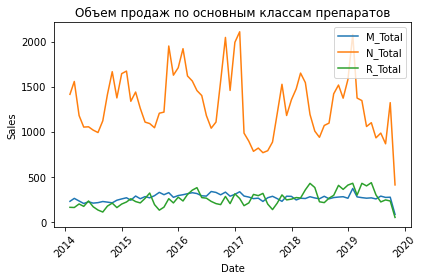

In [18]:
for col in grouped.columns:
    plt.plot(grouped.index, grouped[col], label=col)

plt.legend()
plt.title('Объем продаж по основным классам препаратов')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
total_by_class = grouped[['M_Total','R_Total','N_Total']].sum().sort_values(ascending=False)
class_share = round((total_by_class/total_by_class.sum())*100,2)
class_share

N_Total    71.38
M_Total    14.74
R_Total    13.89
dtype: float64

Класс N формирует более 71% от общего объема продаж

# Сезонность

In [45]:
monthly = monthly.reset_index()

In [46]:
monthly['month'] = monthly['datum'].dt.month_name()


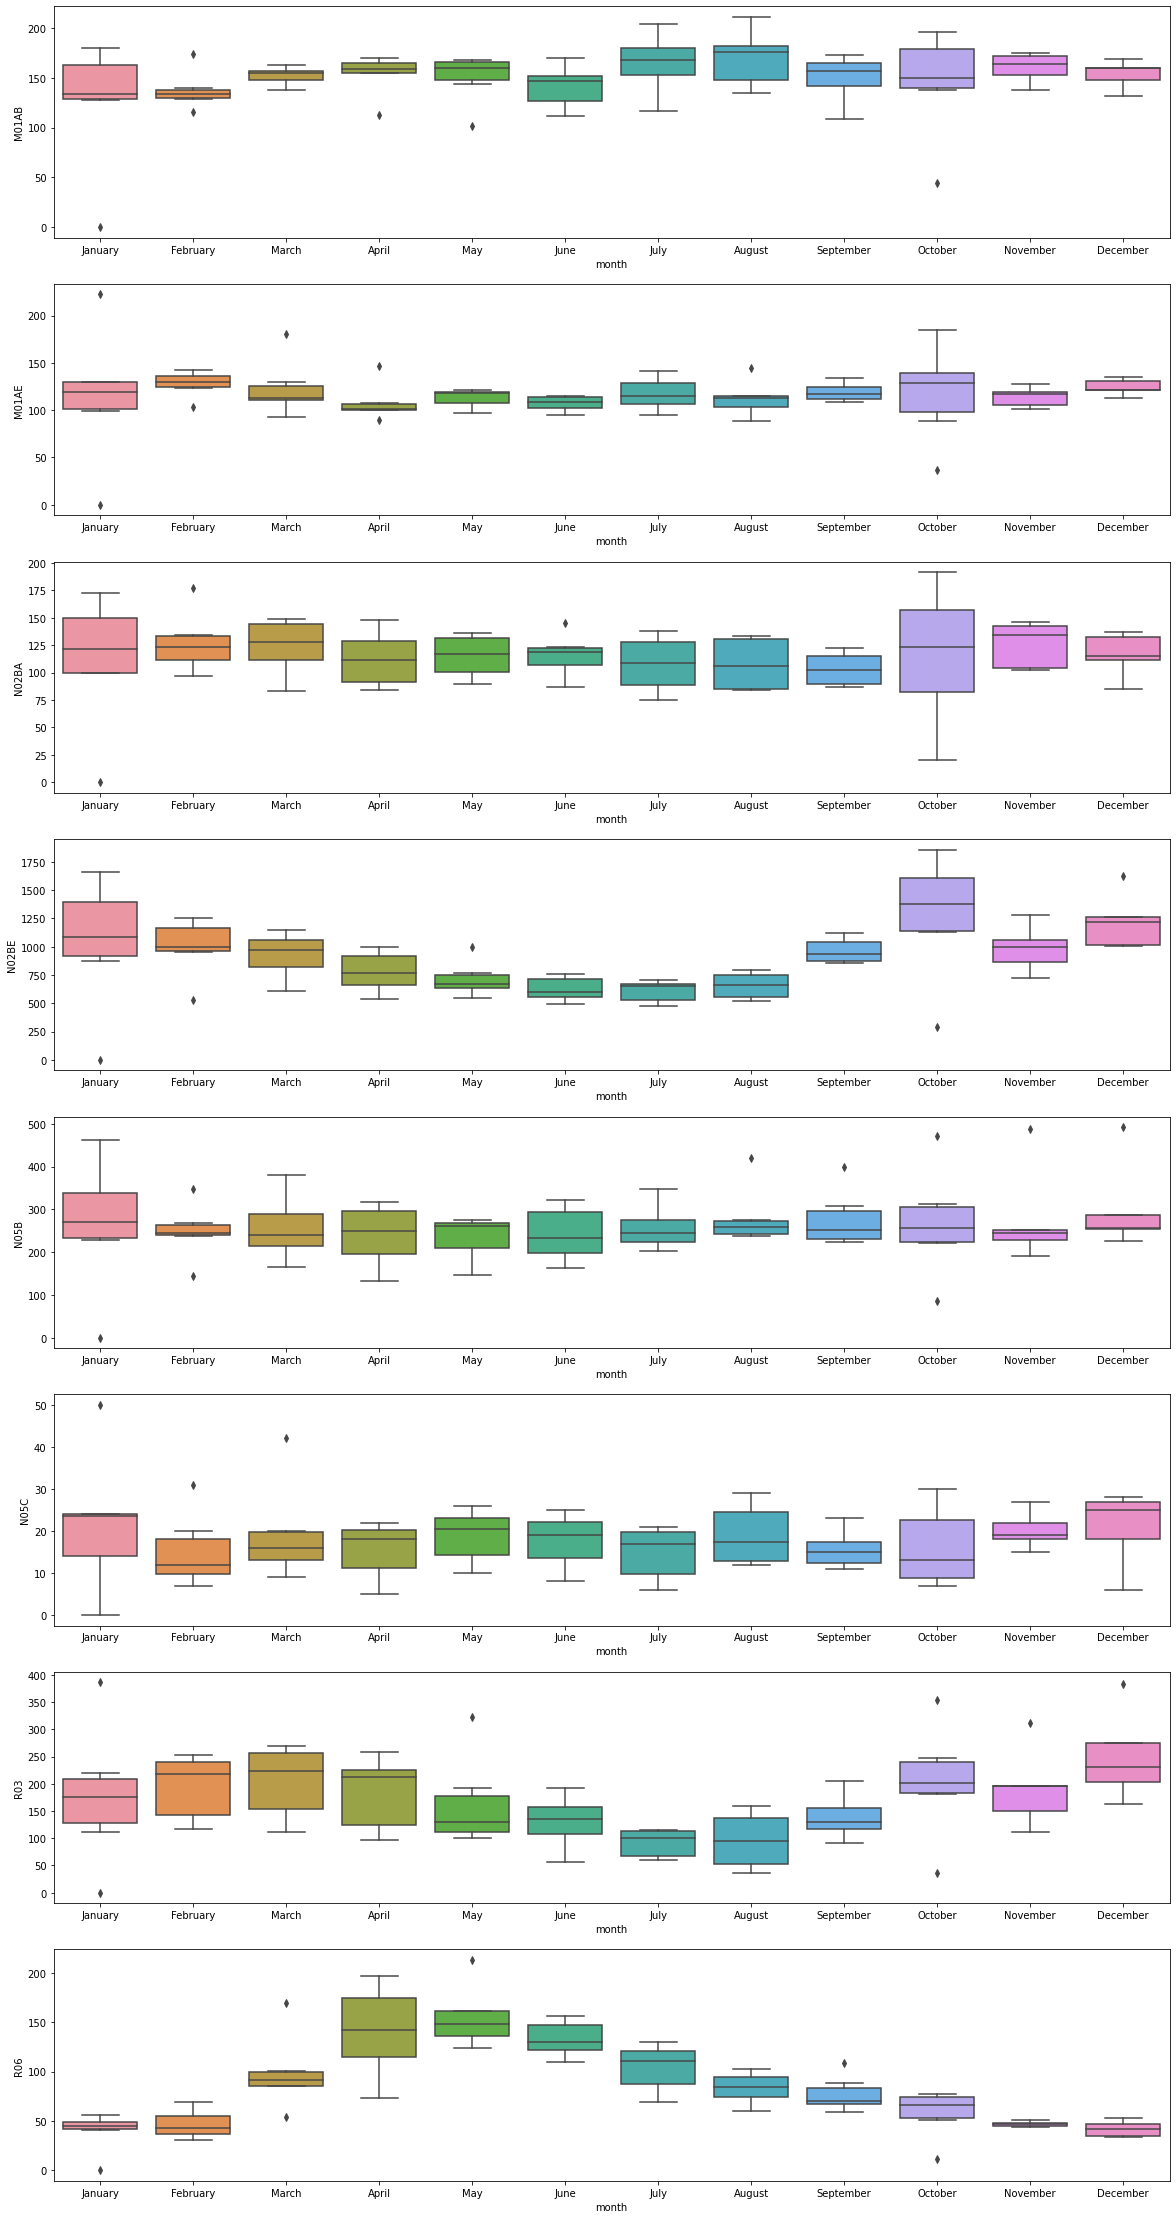

In [47]:
fig, axes = plt.subplots(8, 1, figsize=(20, 40))
for name, ax in zip(['M01AB','M01AE','N02BA','N02BE', 'N05B','N05C','R03','R06'], axes):
    sns.boxplot(data=monthly, x="month", y=name, ax=ax)

На графиках выделяются выбросы в виде точек. 
Также можно выделить определённую сезонность применения препаратов группы R06 (антигистаминные) в весенний период, всвязи с обостреннием аллергических заболеваний. 
Продажи жаропонижающих препаратов повышаются в осенний период. Это связано с пиком заболеваемости ОРВИ.

## Связь между категориями

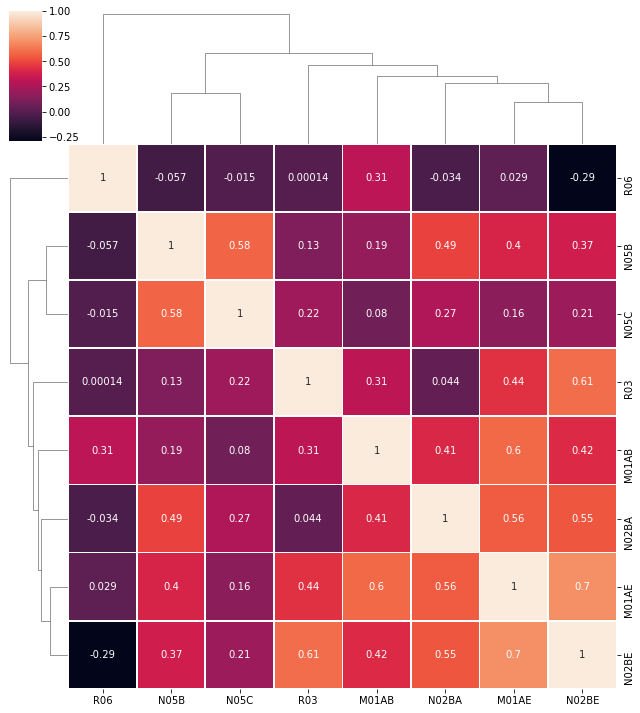

In [26]:
sns.clustermap(monthly.corr(), dendrogram_ratio = (0.1, 0.2), annot = True, linewidths = 0.8, figsize = (9, 10))
plt.show()

Как видно из вышесказанного, выделяются многие двусторонние отношения. Во многом это связано с сходством симптомов заболеваний, при которых  используются эти категории лекарств.
 - MO1AE - NO2BE -- >0.7
 - NO2BE - RO3 --> 0.61
 - NO2BE - M01AE --> 0.56
 
Возможные причины: 
 - общая сезонность
 - рост общей покупательской активности
 - влияние эпидемиологических факторов
 
 
Связка NO2BE(анальгетики)-RO2(дыхательные препараты) может отражать простудные периоды.
Антигистаминные препараты (RO6) демонстрируют слабую и частично отрицательную корреляцию с анальгеттиками, что отражает различие сезонных факторов спроса.
Таким образом, корреляционный анализ выявил наличие категорий препаратов с синхронной динамикой продаж, что может отражать схожие паттерны потребления. 

## Средние продажи по месяцам

In [28]:

seasonanalityc = daily.groupby('Month')[atc].mean()
seasonanalityc.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

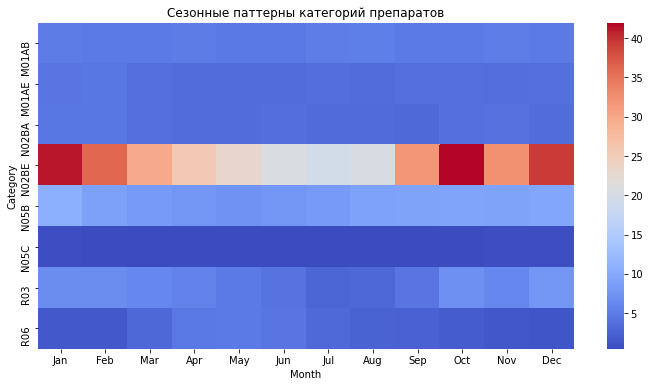

In [29]:

plt.figure(figsize=(12,6))
sns.heatmap(seasonanalityc.T, cmap='coolwarm',annot=False)

plt.title('Сезонные паттерны категорий препаратов')
plt.xlabel('Month')
plt.ylabel('Category')
plt.show()

# Вывод

Проведённый анализ позволил выявить тенденции спроса на каждый класс лекарственных препаратов, колебания объема динамики продажо за два года, корреляции между различными классами лекарственных препаратов
Эти данные могут помочь в планировании более углубленного и целенаправленного анализа для достижения конкретной цели, а также могут служить отправной точкой, например, для создания моделей искусственного интеллекта, которые помогают прогнозировать объем использования определенного лекарственного препарата.